# Influence of Weights and Reference Point on Vistas

This notebook explores how two key parameters shape VISTA visualisations:

1. **Criteria weights** — control the relative importance of each criterion.
2. **Reference point position** — the fixed alternative against which every grid point is compared.

We examine each factor in isolation and then look at their combined effect.

In [1]:
%matplotlib inline

from mcda_vista import generate_vista, plot_vista, plot_vista_grid, VistaResult

## 1. Criteria Weights

Weights allow decision makers to provide preferences concerning the importance of criteria. These preferences typically have an effect on the ranking method, and vistas can help visualize this effect. Here, we will test this by comparing the vistas of TOPSIS, SAW, and ELECTRE III for three sets of criteria weights: [0.25, 0.75], [0.50, 0.50], [0.75, 0.25].

In [3]:
weight_configs = [[0.25, 0.75], [0.50, 0.50], [0.75, 0.25]]
methods = ["topsis", "saw", "electre_iii"]

method_params = {
    "topsis": {"delta": 0.10},
    "saw": {"delta": 0.10},
    "electre_iii": {"q": 0.10, "p": 0.20, "v": 1.0, "alpha": -0.15, "beta": 0.30},
}

results_weights = []
for m in methods:
    row = []
    for w in weight_configs:
        r = generate_vista(
            m,
            resolution=51,
            weights=w,
            progress=False,
            **method_params[m],
        )
        row.append(r)
    results_weights.append(row)

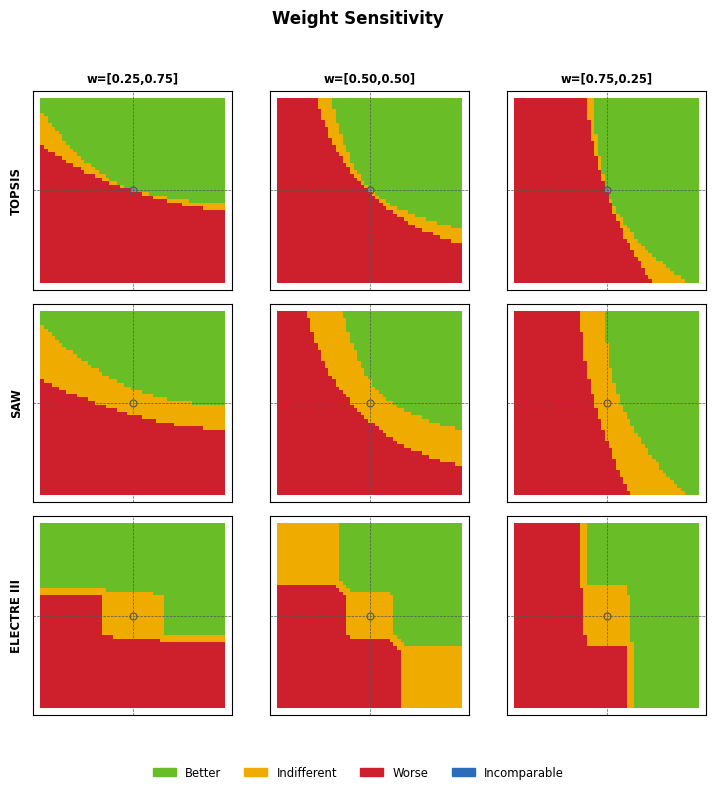

In [9]:
fig = plot_vista_grid(
    results_weights,
    row_labels=["TOPSIS", "SAW", "ELECTRE III"],
    col_labels=["w=[0.25,0.75]", "w=[0.50,0.50]", "w=[0.75,0.25]"],
    title="Weight Sensitivity",
    point_size=5,
)

**Observations:**

- With equal weights (`w=[0.50, 0.50]`) the maps are symmetric about the
  diagonal through the reference point.
- Shifting weight towards criterion 2 (`w=[0.25, 0.75]`) compresses the
  decision boundary along the *x*-axis — changes in criterion 1 matter
  less.
- The reverse holds for `w=[0.75, 0.25]`: the boundary compresses along
  the *y*-axis.
- The effect is consistent across TOPSIS, SAW, and ELECTRE III, though the
  boundary shapes differ due to each method's aggregation logic.

## 2. Reference Point Position

The reference point is the fixed alternative that every point on the VISTA is compared to. Moving the reference point shifts the crosshair
marker and repositions the decision boundaries accordingly.

In [10]:
ref_configs = [[0.25, 0.25], [0.50, 0.50], [0.75, 0.75], [0.25, 0.75]]
ref_methods = ["topsis", "electre_iii"]

ref_method_params = {
    "topsis": {"delta": 0.10},
    "electre_iii": {"q": 0.10, "p": 0.20, "v": 1.0, "alpha": -0.15, "beta": 0.30},
}

results_ref = []
for m in ref_methods:
    row = []
    for ref in ref_configs:
        r = generate_vista(
            m,
            resolution=51,
            reference=ref,
            progress=False,
            **ref_method_params[m],
        )
        row.append(r)
    results_ref.append(row)

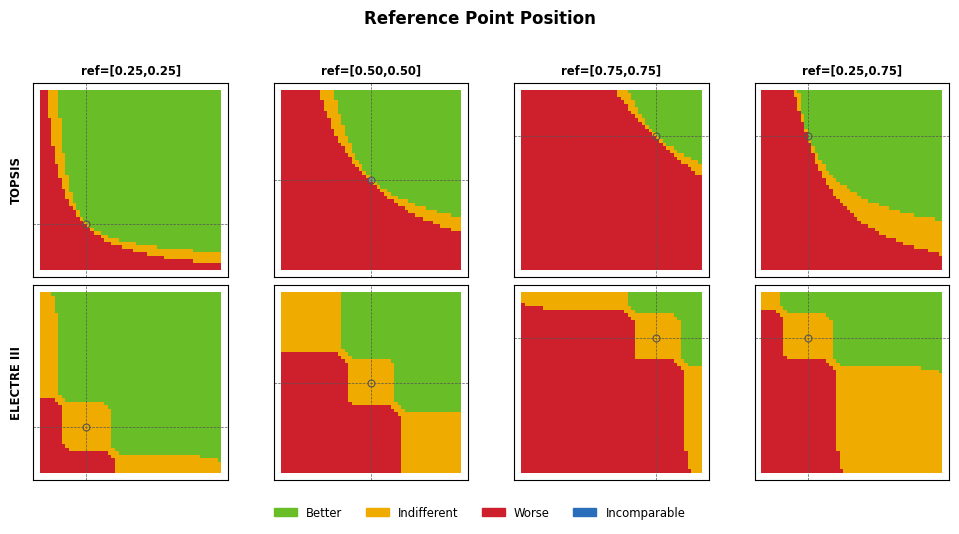

In [13]:
fig = plot_vista_grid(
    results_ref,
    row_labels=["TOPSIS", "ELECTRE III"],
    col_labels=[
        "ref=[0.25,0.25]",
        "ref=[0.50,0.50]",
        "ref=[0.75,0.75]",
        "ref=[0.25,0.75]",
    ],
    title="Reference Point Position",
    point_size=5
)

**Observations:**

- The crosshair and open-circle marker visibly move with the reference
  point, confirming which alternative serves as the comparison baseline.
- Decision boundaries shift accordingly: a reference in the lower-left
  corner produces a large *better* region in the upper-right, while a
  reference in the upper-right corner reverses the pattern.

## 3. Combined Effect: Weights × Reference Point

When both weights and the reference point deviate from their defaults
the effects interact.  Below we use TOPSIS with an asymmetric weight
vector and two different reference positions.

In [14]:
combined_weights = [[0.25, 0.75], [0.75, 0.25]]
combined_refs = [[0.25, 0.25], [0.75, 0.75]]

results_combined = []
for w in combined_weights:
    row = []
    for ref in combined_refs:
        r = generate_vista(
            "topsis",
            resolution=51,
            weights=w,
            reference=ref,
            delta=0.10,
            progress=False
        )
        row.append(r)
    results_combined.append(row)

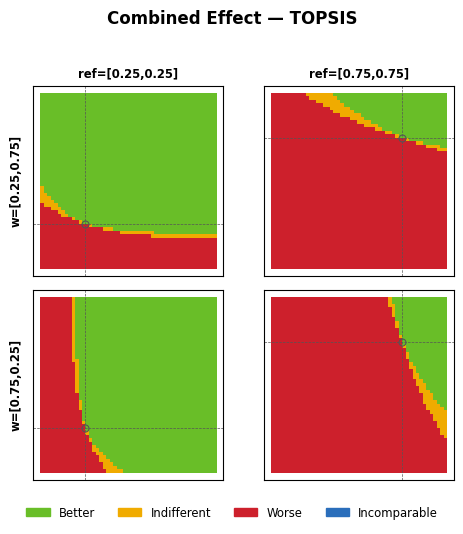

In [15]:
fig = plot_vista_grid(
    results_combined,
    row_labels=["w=[0.25,0.75]", "w=[0.75,0.25]"],
    col_labels=["ref=[0.25,0.25]", "ref=[0.75,0.75]"],
    title="Combined Effect — TOPSIS",
    point_size=5
)

**Observations:**

- Weights and reference position jointly determine the shape and location
  of decision boundaries.
- When the reference point sits in a corner the boundary is already
  shifted; adding unequal weights further tilts it.  The two effects
  can reinforce or partially cancel each other depending on their
  alignment.